In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#  load the data 

df= pd.read_csv('iris_dataset.csv')
# df.head()
# df.info()
df.isnull().sum() # NOT NULL VALUES

df['Species'].value_counts()

df= df.drop(columns='Id',axis=1)

In [ ]:
X= df.drop(columns="Species",  axis=1)
y= df['Species']

In [ ]:
y.value_counts()
print(X.shape) # 150 , 4
# Iris-setosa        50
# Iris-versicolor    50
# Iris-virginica     50


In [ ]:
# histograms for input features 
X.hist(figsize=(10, 7))
plt.tight_layout()

plt.savefig("01_historgrams.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Species',
    y='PetalLengthCm',
    data=df
)

plt.title('Petal Length by Species')
plt.savefig("02_box_plots.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#  co relations 

corr = df.corr(numeric_only=True)

print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.savefig("03_corelation.png", dpi=300, bbox_inches="tight")

plt.show()

#  PetalLengthCm  ↔  PetalWidthCm very strong relation 

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        x='Species',
        y=feature,
        data=df,
        ax=ax
    )

    ax.set_title(f'{feature} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature)
plt.savefig("04_all_box_plots.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
sns.pairplot(
    df,
    hue='Species',
    diag_kind='kde'
)
plt.savefig("05_pairplots.png", dpi=300, bbox_inches="tight")
plt.show()


In [21]:
# Train Test Split
from sklearn.model_selection import train_test_split
X = df.drop('Species', axis=1)
y = df['Species']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


### Logestic Reg

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


### knn Classifiers 

In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


### Naive Bayes

In [23]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9666666666666667


In [27]:
from sklearn.metrics import classification_report

print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_logistic))

print("===== KNN =====")
print(classification_report(y_test, y_pred_knn))

print("===== Naive Bayes =====")
print(classification_report(y_test, y_pred_nb))

===== Logistic Regression =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

===== KNN =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

===== Naive Bayes =====
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-vers

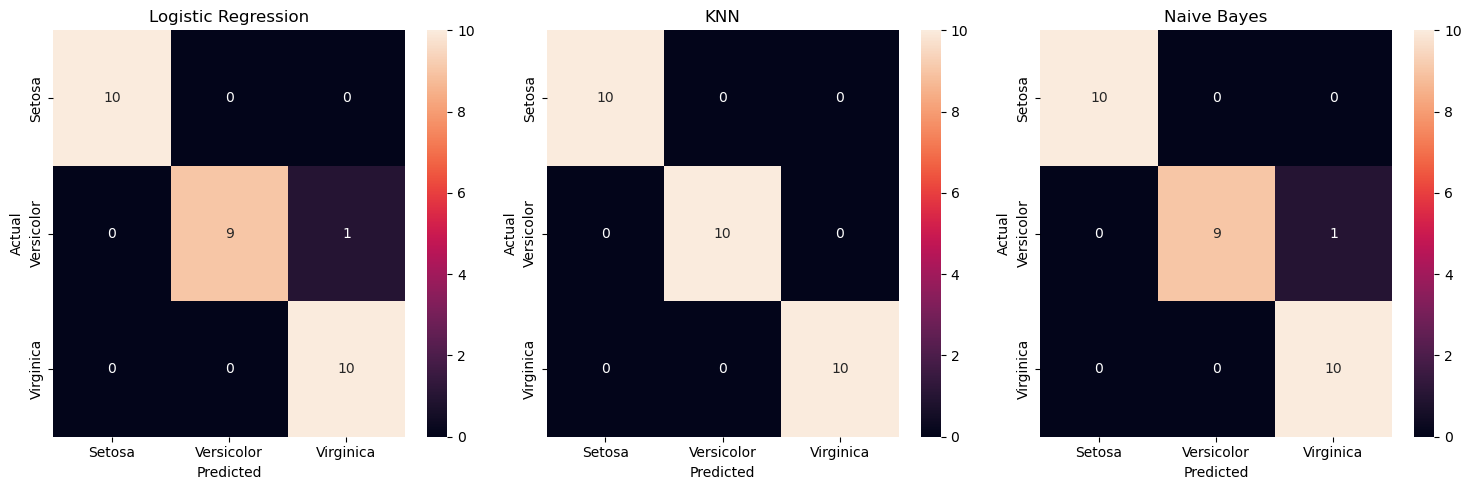

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_predictions = {
    'Logistic Regression': y_pred_logistic,
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (model_name, predictions) in zip(axes, models_predictions.items()):

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=ax,
        xticklabels=['Setosa', 'Versicolor', 'Virginica'],
        yticklabels=['Setosa', 'Versicolor', 'Virginica']
    )

    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig("06_confusion metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Apply scaling

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [33]:
# Logestic Reg
from sklearn.linear_model import LogisticRegression
logistic_scaled = LogisticRegression(max_iter=200)

logistic_scaled.fit(X_train_scaled, y_train)

y_pred_logistic_scaled = logistic_scaled.predict(X_test_scaled)



In [34]:
from sklearn.metrics import accuracy_score

logistic_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_logistic_scaled
)

print(
    "Logistic Regression Accuracy After Scaling:",
    logistic_scaled_accuracy
)

Logistic Regression Accuracy After Scaling: 0.9333333333333333


In [35]:
#  KNN
from sklearn.neighbors import KNeighborsClassifier

knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

knn_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_knn_scaled
)

print(
    "KNN Accuracy After Scaling:",
    knn_scaled_accuracy
)


KNN Accuracy After Scaling: 0.9333333333333333


In [36]:
from sklearn.naive_bayes import GaussianNB

nb_scaled = GaussianNB()

nb_scaled.fit(X_train_scaled, y_train)

y_pred_nb_scaled = nb_scaled.predict(X_test_scaled)

nb_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_nb_scaled
)

print(
    "Naive Bayes Accuracy After Scaling:",
    nb_scaled_accuracy
)

Naive Bayes Accuracy After Scaling: 0.9666666666666667


In [37]:
comparison = {
    'Logistic Regression': [
        logistic_accuracy,
        logistic_scaled_accuracy
    ],
    'KNN': [
        knn_accuracy,
        knn_scaled_accuracy
    ],
    'Naive Bayes': [
        nb_accuracy,
        nb_scaled_accuracy
    ]
}

for model, scores in comparison.items():
    print(f"{model}")
    print(f"  Before Scaling: {scores[0]:.4f}")
    print(f"  After Scaling:  {scores[1]:.4f}")
    print()

Logistic Regression
  Before Scaling: 0.9667
  After Scaling:  0.9333

KNN
  Before Scaling: 1.0000
  After Scaling:  0.9333

Naive Bayes
  Before Scaling: 0.9667
  After Scaling:  0.9667

